In [2]:
from constants import DATA_ROOT_PATH_NAME, BANDPASS, HAMPEL_WINDOW_SIZE, HAMPEL_N_SIGMA, CROP_TMIN, CROP_TMAX, LOCAL_DETREND_WINDOW_SEC, LOCAL_DETREND_STEP_SEC, ASR_CUTOFF, ASR_BLOCKSIZE, ASR_WIN_LEN, ASR_WIN_OVERLAP, ASR_MAX_DROPOUT_FRACTION, ASR_MIN_CLEAN_FRACTION, ASR_MAX_BAD_CHANS

from preprocessing.step.bandpass import BandpassFilterStep
from preprocessing.step.detrend import LocalDetrendStep
from preprocessing.step.hampel import HampelFilterStep
from preprocessing.step.asr import ASRStep
from preprocessing.step.crop import CropStep

from preprocessing.pipeline import PreprocessingPipeline
import numpy as np

from features.factory import FeatureExtractionEngine, FeatureExtractionConfig
from features.categories import FeatureCategory

from eeg.data import EEGRecordedDataProvider

from features.visualization import ExtractedFeatureHeatmapFactory

from features.io import FeatureExtractionResultIO


%load_ext autoreload
%autoreload 2

# Création des 2 datasets de features

In [3]:
recordings = EEGRecordedDataProvider.build(DATA_ROOT_PATH_NAME)

/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-eyesclosed.

The search_str was "data/sub-001/**/eeg/sub-001*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 57
Group: A
MMSE: 16
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-002_task-eyesclosed.

The search_str was "data/sub-002/**/eeg/sub-002*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 78
Group: A
MMSE: 22
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not fin

In [4]:
asr_pipeline = PreprocessingPipeline(name="ASR",
                                        steps=[
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                ASRStep(cutoff=ASR_CUTOFF, blocksize=ASR_BLOCKSIZE, win_len=ASR_WIN_LEN, win_overlap=ASR_WIN_OVERLAP, max_dropout_fraction=ASR_MAX_DROPOUT_FRACTION, min_clean_fraction=ASR_MIN_CLEAN_FRACTION, max_bad_chans=ASR_MAX_BAD_CHANS)
                                                ])

dethamp_pipeline = PreprocessingPipeline(name="det-hamp",
                                        steps=[ 
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                LocalDetrendStep(window_sec=LOCAL_DETREND_WINDOW_SEC, step_sec=LOCAL_DETREND_STEP_SEC),
                                                HampelFilterStep(window_size=HAMPEL_WINDOW_SIZE, n_sigma=HAMPEL_N_SIGMA)
                                                ])

In [5]:
recorded_eeg = recordings[14]
asr_processed_eeg = asr_pipeline.compute(recorded_eeg)
dethamp_processed_eeg = dethamp_pipeline.compute(recorded_eeg)

In [6]:
categories_to_extract = [FeatureCategory.WAVELET, FeatureCategory.TEMPORAL, FeatureCategory.POWER_RATIO, FeatureCategory.SPECTRAL]
config = FeatureExtractionConfig(categories_to_extract=categories_to_extract, wamp_threshold=10e-9, ppc_epoch_duration=2)
feature_extraction_engine = FeatureExtractionEngine(config=config)

dethamp_processed_extraction_result = feature_extraction_engine.extract(dethamp_processed_eeg)
dethamp_processed_extracted_feature_heatmap_factory = ExtractedFeatureHeatmapFactory(dethamp_processed_extraction_result)

asr_processed_extraction_result = feature_extraction_engine.extract(asr_processed_eeg)
asr_processed_extracted_feature_heatmap_factory = ExtractedFeatureHeatmapFactory(asr_processed_extraction_result)

/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:395: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:395: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(


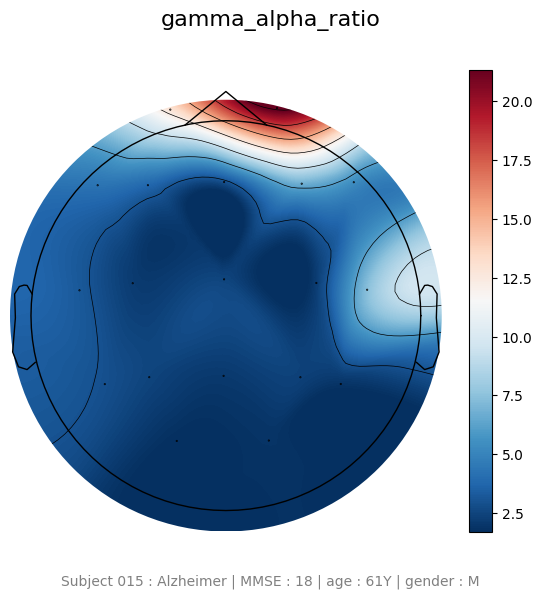

In [7]:
dethamp_processed_extracted_feature_heatmap_factory.plot("gamma_alpha_ratio")

# Tests statistiques